# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

print("Library berhasil diimport!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Library berhasil diimport!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin-1')
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head()

Saving data.csv to data (3).csv
Shape: (13169, 13)
Kolom: ['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
# Informasi dasar dataset
print("Shape:", df.shape)
print("\nInfo Dataset:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (13169, 13)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet          13169 non-null  object
 1   HS             13169 non-null  int64 
 2   Abusive        13169 non-null  int64 
 3   HS_Individual  13169 non-null  int64 
 4   HS_Group       13169 non-null  int64 
 5   HS_Religion    13169 non-null  int64 
 6   HS_Race        13169 non-null  int64 
 7   HS_Physical    13169 non-null  int64 
 8   HS_Gender      13169 non-null  int64 
 9   HS_Other       13169 non-null  int64 
 10  HS_Weak        13169 non-null  int64 
 11  HS_Moderate    13169 non-null  int64 
 12  HS_Strong      13169 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 1.3+ MB

Missing Values:
Tweet            0
HS               0
Abusive          0
HS_Individual    0
HS_Group         0
HS_Religion      0
HS_Race          0
HS_Physical

Distribusi Label HS:
HS
0    7608
1    5561
Name: count, dtype: int64


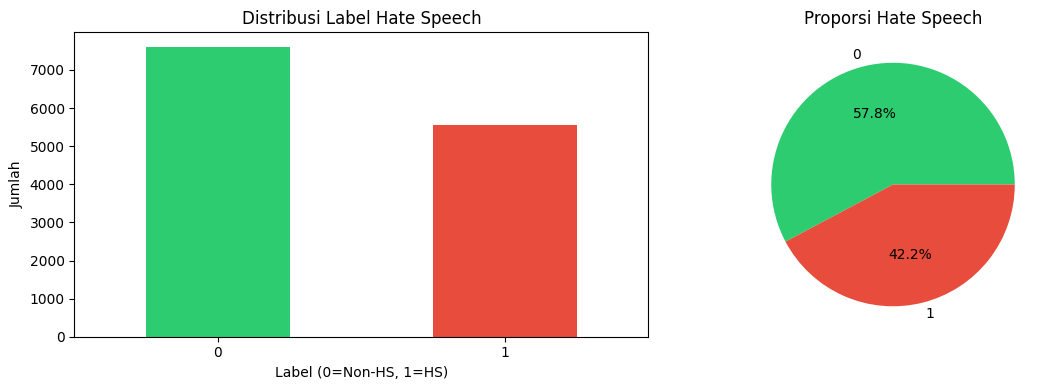

In [7]:
# Distribusi label HS (Hate Speech)
print("Distribusi Label HS:")
print(df['HS'].value_counts())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['HS'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Label Hate Speech')
plt.xlabel('Label (0=Non-HS, 1=HS)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['HS'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                              colors=['#2ecc71', '#e74c3c'])
plt.title('Proporsi Hate Speech')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [8]:
# Analisis panjang teks
df['text_length'] = df['Tweet'].apply(len)
df['word_count'] = df['Tweet'].apply(lambda x: len(str(x).split()))

print("Statistik Panjang Teks:")
print(df['text_length'].describe())
print("\nStatistik Jumlah Kata:")
print(df['word_count'].describe())

Statistik Panjang Teks:
count    13169.000000
mean       114.202749
std         69.075620
min          4.000000
25%         59.000000
50%        100.000000
75%        152.000000
max        561.000000
Name: text_length, dtype: float64

Statistik Jumlah Kata:
count    13169.000000
mean        17.282102
std         10.231973
min          1.000000
25%          9.000000
50%         15.000000
75%         23.000000
max         52.000000
Name: word_count, dtype: float64


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
# Hapus duplikat
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Baris duplikat dihapus: {before - after}")
print(f"Total data setelah hapus duplikat: {after}")

Baris duplikat dihapus: 125
Total data setelah hapus duplikat: 13044


In [10]:
# Fungsi preprocessing teks
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Stopwords
stop_words = set(stopwords.words('indonesian'))
custom_sw = {'yg','nya','ini','itu','dan','di','ke','dari','utk','tdk',
             'gak','ga','ya','aja','jg','sy','dgn','dg','tp','tapi',
             'sdh','udah','dah','jd','rt','user'}
stop_words.update(custom_sw)

def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

print("Melakukan preprocessing...")
df['text_clean'] = df['Tweet'].apply(preprocess_text)
print("Selesai!")
df[['Tweet', 'text_clean', 'HS']].head()

Melakukan preprocessing...
Selesai!


,Tweet,text_clean,HS
0,- disaat semua cowok berusaha melacak perhatia...,disaat cowok berusaha melacak perhatian gue lo...,1
1,RT USER: USER siapa yang telat ngasih tau elu?...,telat ngasih tau eluedan sarap gue bergaul cig...,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",kadang berfikir percaya tuhan jatuh berkalikal...,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,akunnku tau matamu sipit diliat,0
4,USER USER Kaum cebong kapir udah keliatan dong...,kaum cebong kapir keliatan dongoknya dongok ha...,1


In [11]:
# Label encoding dan simpan dataset
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['HS'])

# Simpan hasil preprocessing
df[['Tweet', 'text_clean', 'HS', 'label_encoded']].to_csv('data_preprocessed.csv', index=False)
print("Dataset disimpan!")
print(f"Shape: {df.shape}")
print(f"Distribusi label:\n{df['HS'].value_counts()}")

Dataset disimpan!
Shape: (13044, 17)
Distribusi label:
HS
0    7526
1    5518
Name: count, dtype: int64
